In [5]:
!pip install -qU Flask
!pip install -qU tensorflow
!pip install -qU tensorflow-addons
!pip install -qU pandas
!pip install -qU googletrans langdetect emojis pyarabic emoji


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow-addons
  You can safely remove it manually.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
  DEPRECATION: Building 'langdetect' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly comb

In [6]:
!pip uninstall -y numpy
!pip install "numpy>=1.25,<1.27"

Found existing installation: numpy 2.3.2
Uninstalling numpy-2.3.2:
  Successfully uninstalled numpy-2.3.2


You can safely remove it manually.
You can safely remove it manually.


     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
     -- ------------------------------------- 1.0/15.8 MB 3.8 MB/s eta 0:00:04
     ---- ----------------------------------- 1.8/15.8 MB 3.9 MB/s eta 0:00:04
     ------ --------------------------------- 2.6/15.8 MB 3.9 MB/s eta 0:00:04
     -------- ------------------------------- 3.4/15.8 MB 3.7 MB/s eta 0:00:04
     --------- ------------------------------ 3.9/15.8 MB 3.5 MB/s eta 0:00:04
     ----------- ---------------------------- 4.7/15.8 MB 3.5 MB/s eta 0:00:04
     ------------- -------------------------- 5.5/15.8 MB 3.6 MB/s eta 0:00:03
     --------------- ------------------------ 6.3/15.8 MB 3.6 MB/s eta 0:00:03
     ------------------ --------------------- 7.3/15.8 MB 3.7 MB/s eta 0:00:03
     -------------------- ------------------- 8.1/15.8 MB 3.7 MB/s eta 0:00:03
     ---------------------- ----------------- 8.9/15.8 MB 3.7 MB/s

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.5.3 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas
import seaborn as sns
from sklearn import preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import RegexpTokenizer
from collections import Counter
import re
import string
import matplotlib.cm as cm
from matplotlib import rcParams
from prettytable import PrettyTable
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing
import seaborn as sns
import os
from IPython.display import display, HTML
from googletrans import Translator
from langdetect import detect
import warnings
warnings.filterwarnings("ignore")
from nltk.corpus import stopwords
import re
import csv
import emojis
import pyarabic.araby as araby
from nltk.stem.isri import ISRIStemmer
from nltk.stem import SnowballStemmer
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.regularizers import l1_l2
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#import tensorflow_addons as tfa
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mereh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#Load Data

In [6]:
from sklearn.model_selection import train_test_split

column_names = ["review_description", "rating"]
data = pd.read_excel("../data/train.xlsx", names=column_names)

train_data, test_data = train_test_split(data, test_size=0.2, random_state=42,shuffle=True)

len(train_data), len(test_data)

(25628, 6408)

In [7]:
print("Missing values in train_data:")
print(train_data[train_data.isnull().any(axis=1)].head())

print("\nMissing values in test_data:")
print(test_data[test_data.isnull().any(axis=1)].head())


print("\nSum of missing values per row in train_data:")
print(np.sum(train_data.isnull().any(axis=1)))

print("\nMissing values per column in train_data:")
print(train_data.isnull().any(axis=0))

print("\nSum of missing values per row in test_data:")
print(np.sum(test_data.isnull().any(axis=1)))

print("\nMissing values per column in test_data:")
print(test_data.isnull().any(axis=0))

Missing values in train_data:
Empty DataFrame
Columns: [review_description, rating]
Index: []

Missing values in test_data:
Empty DataFrame
Columns: [review_description, rating]
Index: []

Sum of missing values per row in train_data:
0

Missing values per column in train_data:
review_description    False
rating                False
dtype: bool

Sum of missing values per row in test_data:
0

Missing values per column in test_data:
review_description    False
rating                False
dtype: bool


In [8]:
train_data["review_description"] = train_data["review_description"].astype(str)
test_data["review_description"] = test_data["review_description"].astype(str)

train_data["review_description"] = train_data["review_description"].fillna({"review_description":"مجهول"})
test_data["review_description"]  =test_data["review_description"].fillna({"review_description":"مجهول"})

train_data, test_data

(                                      review_description  rating
 8087                                         انصحك تنزله       1
 14853  مانزلته لان سمعت مهكر ويسحبون مبالغ من بطاقة ا...      -1
 12477               رائعين ومتميزين ..خدمة ومصداقية 100%       1
 3753                                    يحتاج متاجر اكثر      -1
 20302                            المشكلة مفيش مطاعم سوشي       1
 ...                                                  ...     ...
 29802        لماذا لايظهر موقع المطاعم ومعرفة مكانها فين       0
 5390   التطبيق جميل جدا جدا جدا و رهيب لكن عندي كلمه ...       1
 860                                         ممتاز ومعتمد       1
 15795     يصل متاخر الطلب و رسوم التوصيل لماذا لكن متاخر       1
 23654                              البرنامج سيئ ولا يعمل      -1
 
 [25628 rows x 2 columns],
                                       review_description  rating
 22802                        الثلاثاء القادم مرحبا بك يا       1
 6087   اعجبني بصراحة وما احس الاسعار فية غالية

# preprocessing

In [9]:
for letter in '#.][!XR':
    train_data["review_description"] = train_data["review_description"].astype(str).str.replace(letter,'')
    test_data["review_description"] = test_data["review_description"].astype(str).str.replace(letter,'')

train_data.replace('', np.nan, inplace=True)  #'' row

train_data["review_description"] = train_data["review_description"].fillna({"review_description":"مجهول"})
print(train_data["review_description"].isnull().sum())

3


In [10]:
def translate_EtoA(english_text):

    translator = Translator(service_urls=['translate.google.com'],to_lang="ar")
    translation = translator.translate(english_text)
    arabic_text = translation

    return arabic_text

In [11]:
def remove_punctuations(text):
    translator = str.maketrans('', '', punctuations_list)
    return text.translate(translator)

In [12]:
def remove_repeating_char(text):
    return re.sub(r'(.)\2+', r'\1', text)

In [13]:
def remove_stop_words(text):
    stop_words = set(stopwords.words('arabic')) - {'نعم','لا', 'ليس', 'ليست', 'مش', 'ما','غير','أقبل','ليس','ليسا','ليست','ليستا','ليسوا','لست','لستم','لستما','لستن','لسن','لسنا','واو'}
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(text)
    return " ".join([word for word in tokens if word not in stop_words])

In [14]:
def build_emoji_dictionary(csv_file):
    emoji_dict = {}
    with open(csv_file, 'r', encoding='utf-8') as file:
        reader = csv.reader(file)
        for row in reader:
            emoji = row[0]
            text = row[1]
            emoji_dict[emoji] = text
    return emoji_dict

In [15]:
import emoji

def replace_emojis(emoji_dict, sentence):
    # Convert emojis in the sentence to their textual descriptions
    sentence = emoji.demojize(sentence)

    # Iterate through the emoji dictionary to replace with the custom format
    for key, value in emoji_dict.items():
        sentence = sentence.replace(':' + key + ':', '*' + value + '* ')

    return sentence


In [16]:
def remove_emojis(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

In [17]:
def decode_emojis(text):
    decoded_text = emojis.decode(text)
    return decoded_text

In [18]:
def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)
    return text

In [19]:
def remove_diactrics(text):
    return araby.strip_diacritics(text)

In [21]:
arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:\"?.,'{}~¦+|!”…”–ـ'''
english_punctuations = string.punctuation
punctuations_list = arabic_punctuations + english_punctuations

import emoji
import re
import string

emoji_dict = build_emoji_dictionary("../data/emojis.csv")

def remove_repeating_char(text):
    return re.sub(r'(.)\\1+', r'\\1', text)

def processPost(text,emoji_dict):
    text = re.sub(r"\\s+", " ", str(text).strip())
    text = re.sub('@[^\\s]+', ' ', text)
    text = re.sub('((www\\.[^\\s]+)|(https?://[^\\s]+))',' ',text)
    text = re.sub(r'\\d+', '', text)
    text = re.sub(r'#([^\\s]+)', r'\\1', text)
    text= remove_punctuations(text)
    text = normalize_arabic(text)
    text = replace_emojis(emoji_dict, text)
    text= remove_punctuations(text)
    text = remove_repeating_char(text)
    text = remove_diactrics(text)
    return text

train_data["review_description"] = train_data["review_description"].fillna({"review_description":"مجهول"})
print(train_data["review_description"].isnull().sum())
train_data["review_description"] = train_data["review_description"].apply(lambda x: processPost(x,emoji_dict))
test_data["review_description"] = test_data["review_description"].apply(lambda x: processPost(x,emoji_dict))

3


In [22]:
train_data.replace('', np.nan, inplace=True)
train_data["review_description"] = train_data["review_description"].fillna({"review_description":"مجهول"})
print("train data",train_data["review_description"].isnull().sum())

test_data.replace('', np.nan, inplace=True)
test_data["review_description"] = test_data["review_description"].fillna({"review_description":"مجهول"})
print("test data", test_data["review_description"].isnull().sum())

train data 13
test data 3


In [23]:
tokenizer = RegexpTokenizer(r'\w+')
train_data["review_description"] = train_data["review_description"].apply(str)
train_data["review_description"] = train_data["review_description"].apply(tokenizer.tokenize)

In [24]:
def stem(text):
    stemmed = []
    for word in text:
        stemmed.append(stemmer.stem(word))
    return stemmed

In [25]:
def engstem(text):
    e_stemmer = SnowballStemmer("english")
    stemmed = []
    for word in text:
        stemmed.append(e_stemmer.stem(word))
    return stemmed

In [26]:
stemmer = ISRIStemmer()

train_data["review_description"] = train_data["review_description"].apply(engstem)
train_data["review_description"] = train_data["review_description"].apply(lambda x: ' '.join(x))

train_data["review_description"]

8087                                           انصحك تنزله
14853    مانزلته لان سمعت مهكر ويسحبون مبالغ من بطاقه ا...
12477                    راءعين ومتميزين خدمه ومصداقيه 100
3753                                      يحتاج متاجر اكثر
20302                              المشكله مفيش مطاعم سوشي
                               ...                        
29802          لماذا لايظهر موقع المطاعم ومعرفه مكانها فين
5390     التطبيق جميل جدا جدا جدا و رهيب لكن عندي كلمه ...
860                                           ممتاز ومعتمد
15795       يصل متاخر الطلب و رسوم التوصيل لماذا لكن متاخر
23654                                البرنامج سيء ولا يعمل
Name: review_description, Length: 25628, dtype: str

# Tokenization and Embedding

In [27]:
X_train = train_data['review_description']
y_train = train_data['rating']
x_test = test_data['review_description'].astype(str).tolist()
y_test = test_data['rating']

In [45]:
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

with open('../models/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

X_tokenized = tokenizer.texts_to_sequences(X_train)
# Ensure all elements in x_test are strings before tokenizing
x_test_cleaned = [str(item) for item in x_test]
X_tokenized_test = tokenizer.texts_to_sequences(x_test_cleaned)

max_len = max([len(x) for x in X_tokenized])
print(max_len)
X_padded = pad_sequences(X_tokenized, maxlen=max_len, padding='post')
X_test_padded = pad_sequences(X_tokenized_test, maxlen=max_len, padding='post')

374


In [29]:
y_train = np.array(y_train)

# Filter out NaN values from y_train and X_padded
nan_mask = ~np.isnan(y_train)
y_train_filtered = y_train[nan_mask]
X_padded = X_padded[nan_mask] # Apply the same mask to X_padded

# Shift labels
y_train_shifted = y_train_filtered + 1

# Convert to categorical
y_train_encoded = to_categorical(y_train_shifted, num_classes=3)

# Predict the sentiments

In [30]:
def prediction_test(model):
  predictions = model.predict(X_test_padded)
  predicted_classes = predictions.argmax(axis=-1) # 0.3 0.5 0.2 --> 1
  predicted_classes = np.vectorize({2: -1, 1: 1, 0: 0}.get)(predicted_classes)  # To shift (0, 1, 2) to (-1, 0, 1)
  return predicted_classes

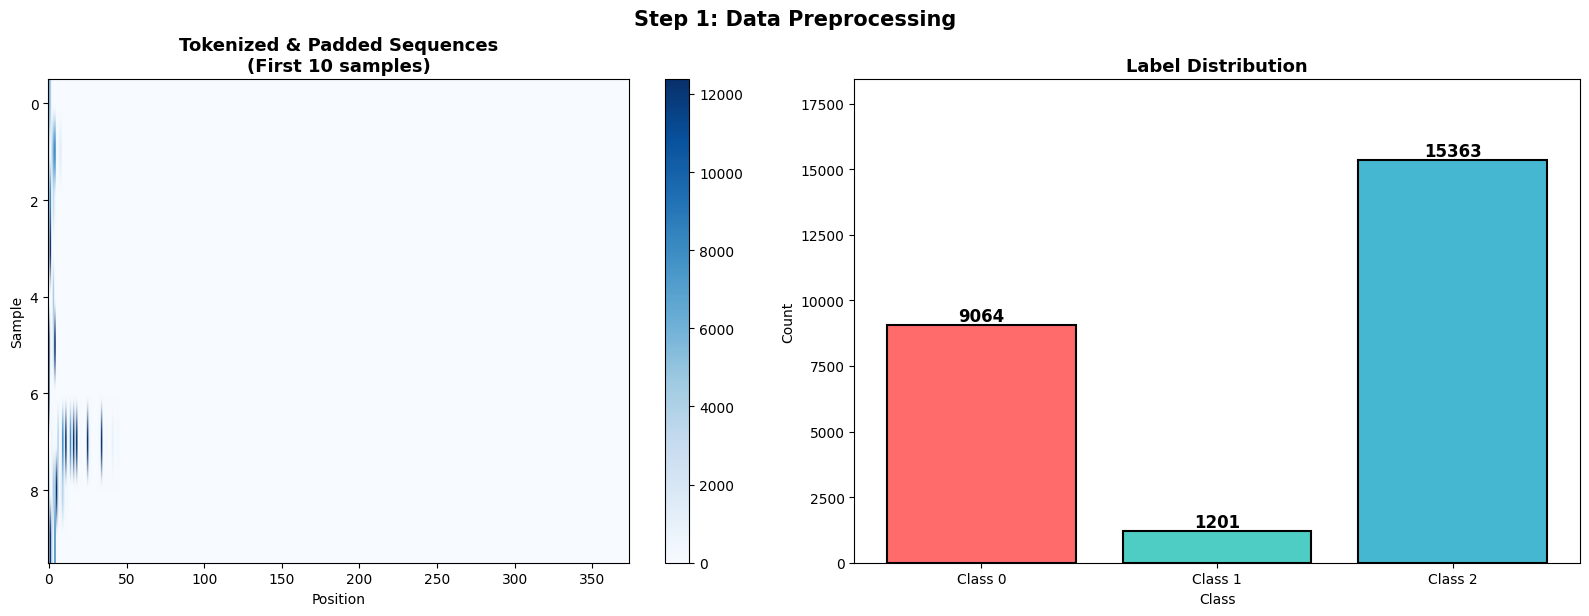

In [31]:
# Visualize tokenized data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tokenized sequences
ax1 = axes[0]
im1 = ax1.imshow(X_padded[:10], cmap='Blues', aspect='auto')
ax1.set_title('Tokenized & Padded Sequences\n(First 10 samples)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Position')
ax1.set_ylabel('Sample')
plt.colorbar(im1, ax=ax1)

# Label distribution
ax2 = axes[1]
label_counts = np.sum(y_train_encoded, axis=0)
bars = ax2.bar(['Class 0', 'Class 1', 'Class 2'], label_counts,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', linewidth=1.5)
ax2.set_title('Label Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Class')
ax2.set_ylabel('Count')
ax2.set_ylim(0, max(label_counts) * 1.2)

for bar, count in zip(bars, label_counts):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            str(int(count)), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.suptitle('Step 1: Data Preprocessing', fontsize=15, fontweight='bold', y=1.02)
plt.show()

In [32]:
print("\n📌 STEP 2: TRANSFORMER COMPONENTS")
print("-" * 50)

# Configuration
VOCAB_SIZE = len(tokenizer.word_index) + 1
D_MODEL = 64           # Embedding dimension
NUM_HEADS = 4          # Number of attention heads
NUM_LAYERS = 2         # Number of encoder layers
D_FF = 128             # Feed-forward dimension
MAX_LEN = max_len      # Maximum sequence length
DROPOUT_RATE = 0.3    # Dropout rate
NUM_CLASSES = 3        # Number of output classes

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Model dimension (d_model): {D_MODEL}")
print(f"Number of attention heads: {NUM_HEADS}")
print(f"Number of encoder layers: {NUM_LAYERS}")
print(f"Feed-forward dimension: {D_FF}")
print(f"Maximum sequence length: {MAX_LEN}")
print(f"Number of classes: {NUM_CLASSES}")


class PositionalEncoding(tf.keras.layers.Layer):
    """Positional Encoding using sine/cosine functions"""
    def __init__(self, max_len, d_model, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len # Store as attribute for get_config
        self.d_model = d_model # Store as attribute for get_config
        self.dropout_rate = dropout_rate # Store as attribute for get_config
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

        # Create positional encoding matrix
        angle_rads = self._get_angles(
            np.arange(max_len)[:, np.newaxis],
            np.arange(d_model)[np.newaxis, :],
            d_model
        )

        # Apply sin to even indices, cos to odd indices
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        # Add batch dimension: (1, max_len, d_model)
        self.pos_encoding = tf.cast(angle_rads[np.newaxis, ...], tf.float32)

    def _get_angles(self, pos, i, d_model):
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        return pos * angle_rates

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        x = x + self.pos_encoding[:, :seq_len, :]
        return self.dropout(x, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({
            'max_len': self.max_len,
            'd_model': self.d_model,
            'dropout_rate': self.dropout_rate,
        })
        return config


def scaled_dot_product_attention(q, k, v, mask=None):
    """Scaled Dot-Product Attention"""
    d_k = tf.cast(tf.shape(k)[-1], tf.float32)

    # Q × K^T
    matmul_qk = tf.matmul(q, k, transpose_b=True)

    # Scale by sqrt(d_k)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(d_k)

    # Apply mask
    if mask is not None:
        scaled_attention_logits += (mask * -1e9)

    # Softmax
    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)

    # Multiply by V
    output = tf.matmul(attention_weights, v)

    return output, attention_weights


class MultiHeadAttention(tf.keras.layers.Layer):
    """Multi-Head Attention Mechanism"""
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads

        # Linear projections
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)
        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        """Split last dimension into (num_heads, d_k)"""
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.d_k))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask=None):
        batch_size = tf.shape(q)[0]

        # Linear projections
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)

        # Split into heads
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # Attention
        scaled_attention, attention_weights = scaled_dot_product_attention(q, k, v, mask)

        # Concatenate heads
        concat_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(concat_attention, (batch_size, -1, self.d_model))

        # Final projection
        output = self.dense(concat_attention)

        return output, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({
            'd_model': self.d_model,
            'num_heads': self.num_heads,
        })
        return config


class FeedForward(tf.keras.layers.Layer):
    """Position-wise Feed-Forward Network"""
    def __init__(self, d_model, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model # Store as attribute for get_config
        self.d_ff = d_ff       # Store as attribute for get_config
        self.dropout_rate = dropout_rate # Store as attribute for get_config
        self.dense1 = tf.keras.layers.Dense(d_ff, activation='relu')
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        self.dense2 = tf.keras.layers.Dense(d_model)

    def call(self, x, training=False):
        x = self.dense1(x)
        x = self.dropout(x, training=training)
        x = self.dense2(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            'd_model': self.d_model,
            'd_ff': self.d_ff,
            'dropout_rate': self.dropout_rate,
        })
        return config


class AddNorm(tf.keras.layers.Layer):
    """Residual Connection + Layer Normalization"""
    def __init__(self, d_model, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model # Store as attribute for get_config (even if not directly used in call)
        self.dropout_rate = dropout_rate # Store as attribute for get_config
        self.layer_norm = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, sublayer_output, training=False):
        residual = x + self.dropout(sublayer_output, training=training)
        return self.layer_norm(residual)

    def get_config(self):
        config = super().get_config()
        config.update({
            'd_model': self.d_model,
            'dropout_rate': self.dropout_rate,
        })
        return config


class EncoderLayer(tf.keras.layers.Layer):
    """Single Transformer Encoder Layer"""
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model # Store as attribute for get_config
        self.num_heads = num_heads # Store as attribute for get_config
        self.d_ff = d_ff # Store as attribute for get_config
        self.dropout_rate = dropout_rate # Store as attribute for get_config

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout_rate)
        self.add_norm_1 = AddNorm(d_model, dropout_rate)
        self.add_norm_2 = AddNorm(d_model, dropout_rate)

    def call(self, x, mask=None, training=False):
        # Multi-Head Attention
        attn_output, attn_weights = self.mha(v=x, k=x, q=x, mask=mask)
        out1 = self.add_norm_1(x, attn_output, training=training)

        # Feed Forward
        ffn_output = self.ffn(out1, training=training)
        out2 = self.add_norm_2(out1, ffn_output, training=training)

        return out2, attn_weights

    def get_config(self):
        config = super().get_config()
        config.update({
            'd_model': self.d_model,
            'num_heads': self.num_heads,
            'd_ff': self.d_ff,
            'dropout_rate': self.dropout_rate,
        })
        return config


📌 STEP 2: TRANSFORMER COMPONENTS
--------------------------------------------------
Vocabulary size: 34905
Model dimension (d_model): 64
Number of attention heads: 4
Number of encoder layers: 2
Feed-forward dimension: 128
Maximum sequence length: 374
Number of classes: 3


In [32]:
!pip install -q gensim

In [33]:
from gensim.models import Word2Vec
import numpy as np

sentences = train_data["review_description"].apply(
    lambda x: x.split()
).tolist()

word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10
)

print("Word2Vec trained successfully!")
print("Vocabulary size:", len(word2vec_model.wv))
print("Embedding dimension:", word2vec_model.wv.vector_size)


Word2Vec trained successfully!
Vocabulary size: 12367
Embedding dimension: 300


In [34]:
WORD2VEC_DIM = word2vec_model.wv.vector_size

embedding_matrix = np.zeros(
    (VOCAB_SIZE, WORD2VEC_DIM),
    dtype=np.float32
)

for word, index in tokenizer.word_index.items():

    if index >= VOCAB_SIZE:
        continue

    if word in word2vec_model.wv:
        embedding_matrix[index] = word2vec_model.wv[word]

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (34905, 300)



 STEP 3: COMPLETE TRANSFORMER ENCODER MODEL
--------------------------------------------------
Model Architecture:
--------------------------------------------------


Model: "transformer_encoder_classifier_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │    10,471,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (1, 374, 64)           │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_2           │ ?                      │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_4 (EncoderLayer)  │ ?                      │        33,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_5 (EncoderLayer)  │ ?                      │        33,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (1, 3)                 │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,562,063 (40.29 MB)

 Trainable params: 10,562,063 (40.29 MB)

 Non-trainable params: 0 (0.00 B)

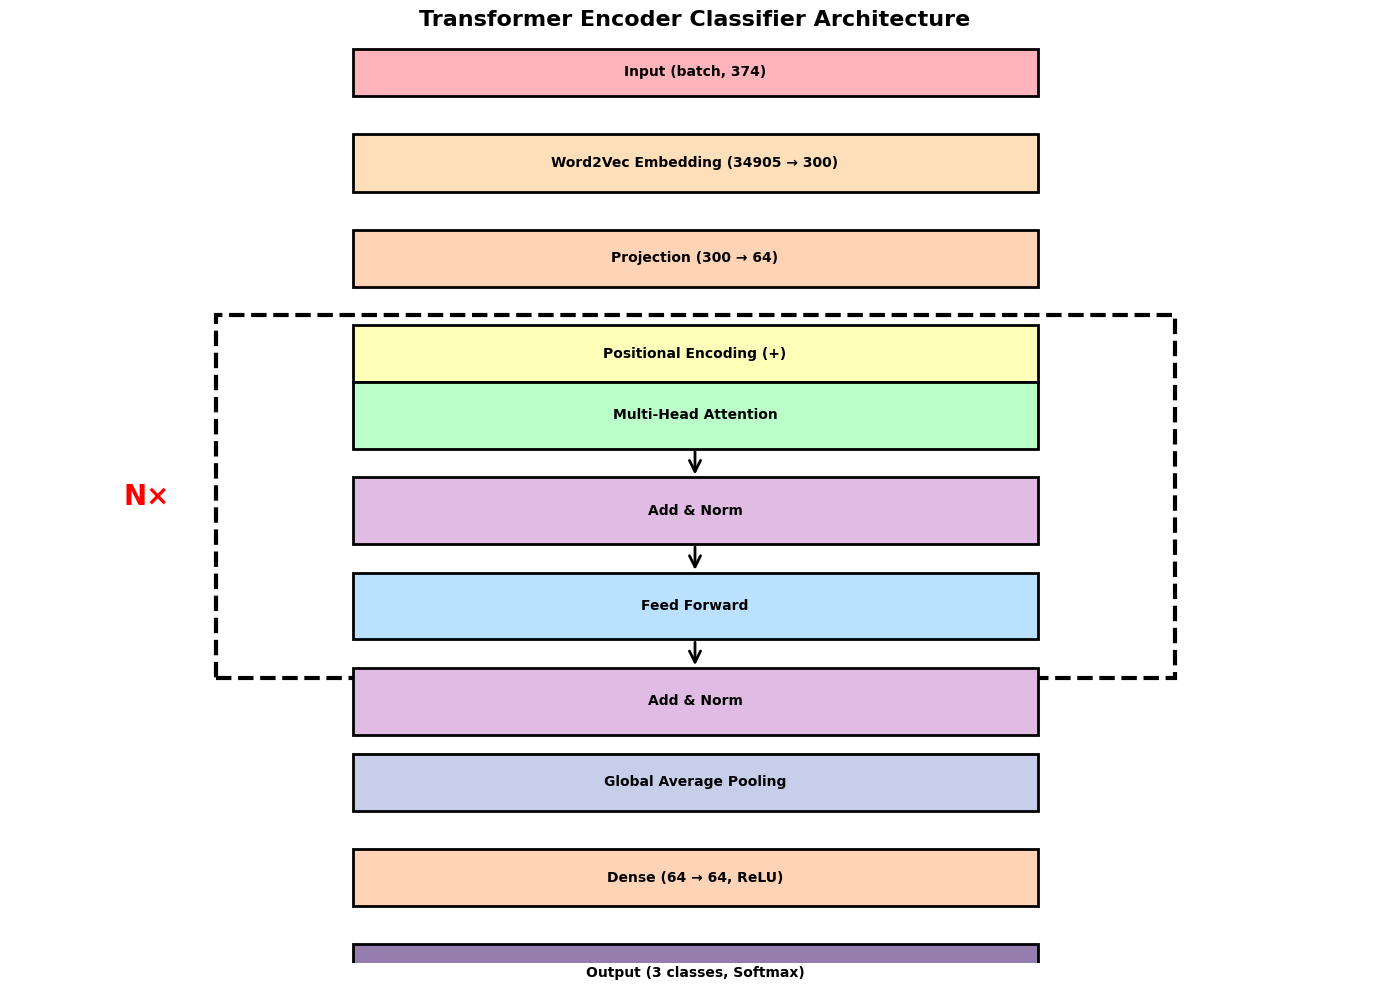

In [46]:
import tensorflow as tf

# ============================================================
# STEP 3: COMPLETE TRANSFORMER ENCODER MODEL
# ============================================================
print("\n STEP 3: COMPLETE TRANSFORMER ENCODER MODEL")
print("-" * 50)


class TransformerEncoderClassifier(tf.keras.Model):
    """
    Transformer Encoder for Text Classification
    """
    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_len, num_classes, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.num_layers = num_layers
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.num_heads = num_heads
        self.d_ff = d_ff
        self.max_len = max_len
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate

        # Embedding layer
        # Word2Vec Embedding
        self.embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=WORD2VEC_DIM,  # 300
            weights=[embedding_matrix],
            trainable=True,
            mask_zero=True
        )

        # Project Word2Vec dimension: 300 → d_model: 64
        self.embedding_projection = tf.keras.layers.Dense(
            d_model
        )
        # Positional encoding
        self.pos_encoding = PositionalEncoding(max_len, d_model, dropout_rate)

        # Encoder layers
        self.enc_layers = [
            EncoderLayer(d_model, num_heads, d_ff, dropout_rate)
            for _ in range(num_layers)
        ]

        self.dropout = tf.keras.layers.Dropout(dropout_rate)

        # Classification head
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling1D()
        self.dense1 = tf.keras.layers.Dense(d_model, activation='relu')
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
        self.output_layer = tf.keras.layers.Dense(num_classes, activation='softmax')

        # Initialize attribute to store attention weights
        self._attention_weights_list = []

    def call(self, x, mask=None, training=False):
                # Word2Vec Embedding
        x = self.embedding(x)
        # Shape: (batch, seq_len, 300)

        # Project 300 → 64
        x = self.embedding_projection(x)
        # Shape: (batch, seq_len, 64)

        # Scale embeddings
        x *= tf.math.sqrt(
            tf.cast(self.d_model, tf.float32)
        )

        # Positional encoding
        x = self.pos_encoding(
            x,
            training=training
        )
        x = self.dropout(x, training=training)

        # Clear attention weights list for a new call
        self._attention_weights_list = []

        # Encoder layers
        for i, enc_layer in enumerate(self.enc_layers):
            # Pass mask and training as keyword arguments
            x, attn_weights = enc_layer(x, mask=mask, training=training)
            # Only collect attention weights if not in training mode
            if not training:
                self._attention_weights_list.append(attn_weights)

        # Global average pooling
        x = self.global_avg_pool(x)  # (batch, d_model)

        # Classification head
        x = self.dense1(x)
        x = self.dropout2(x, training=training)
        output = self.output_layer(x)  # (batch, num_classes)

        # Always return only the main output for compatibility with model.fit
        # Attention weights are stored in self._attention_weights_list for inspection
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'vocab_size': self.vocab_size,
            'd_model': self.d_model,
            'num_heads': self.num_heads,
            'num_layers': self.num_layers,
            'd_ff': self.d_ff,
            'max_len': self.max_len,
            'num_classes': self.num_classes,
            'dropout_rate': self.dropout_rate,
        })
        return config

# CREATE MODEL

model = TransformerEncoderClassifier(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE
)

# BUILD MODEL WITH REAL FORWARD PASS

dummy_input = tf.zeros(
    (1, MAX_LEN),
    dtype=tf.int32
)

_ = model(
    dummy_input,
    training=False
)

# MODEL SUMMARY

print("Model Architecture:")
print("-" * 50)

model.summary()

# Visualize model architecture
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

# Draw architecture
y_pos = 0.95
box_width = 0.5
box_height = 0.06

def draw_box(ax, x, y, w, h, color, text, fontsize=10):
    from matplotlib.patches import Rectangle
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold')

def draw_arrow(ax, x1, y1, x2, y2):
    from matplotlib.patches import FancyArrowPatch
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20, color='black', linewidth=2)
    ax.add_patch(arrow)

# Input
draw_box(ax, 0.25, y_pos - 0.04, 0.5, 0.05, '#FFB3BA', f'Input (batch, {MAX_LEN})')
y_pos -= 0.1

# Word2Vec Embedding
draw_box(
    ax,
    0.25,
    y_pos - 0.04,
    0.5,
    0.06,
    '#FFDFBA',
    f'Word2Vec Embedding ({VOCAB_SIZE} → {WORD2VEC_DIM})'
)
y_pos -= 0.1

# Projection: 300 → 64
draw_box(
    ax,
    0.25,
    y_pos - 0.04,
    0.5,
    0.06,
    '#FFD3B6',
    f'Projection ({WORD2VEC_DIM} → {D_MODEL})'
)
y_pos -= 0.1

# Positional Encoding
draw_box(
    ax,
    0.25,
    y_pos - 0.04,
    0.5,
    0.06,
    '#FFFFBA',
    'Positional Encoding (+)'
)

# N× Encoder Layers
n_box_y = y_pos - 0.35
from matplotlib.patches import Rectangle
rect = Rectangle((0.15, n_box_y), 0.7, 0.38,
                 facecolor='none', edgecolor='black', linewidth=3, linestyle='--')
ax.add_patch(rect)
ax.text(0.1, n_box_y + 0.19, 'N×', ha='center', va='center',
        fontsize=20, fontweight='bold', color='red')

# Inside N× block
y_mha = n_box_y + 0.28
draw_box(ax, 0.25, y_mha - 0.04, 0.5, 0.07, '#BAFFC9', 'Multi-Head Attention')

y_an1 = n_box_y + 0.18
draw_box(ax, 0.25, y_an1 - 0.04, 0.5, 0.07, '#E0BBE4', 'Add & Norm')

y_ffn = n_box_y + 0.08
draw_box(ax, 0.25, y_ffn - 0.04, 0.5, 0.07, '#BAE1FF', 'Feed Forward')

y_an2 = n_box_y - 0.02
draw_box(ax, 0.25, y_an2 - 0.04, 0.5, 0.07, '#E0BBE4', 'Add & Norm')

# Arrows inside N×
draw_arrow(ax, 0.5, y_mha - 0.04, 0.5, y_an1 + 0.03)
draw_arrow(ax, 0.5, y_an1 - 0.04, 0.5, y_ffn + 0.03)
draw_arrow(ax, 0.5, y_ffn - 0.04, 0.5, y_an2 + 0.03)

y_pos = n_box_y - 0.1

# Global Average Pooling
draw_box(ax, 0.25, y_pos - 0.04, 0.5, 0.06, '#C7CEEA', 'Global Average Pooling')
y_pos -= 0.1

# Dense
draw_box(ax, 0.25, y_pos - 0.04, 0.5, 0.06, '#FFD3B6', f'Dense ({D_MODEL} → {D_MODEL}, ReLU)')
y_pos -= 0.1

# Output
draw_box(ax, 0.25, y_pos - 0.04, 0.5, 0.06, '#957DAD', f'Output ({NUM_CLASSES} classes, Softmax)')

ax.text(0.5, 0.99, 'Transformer Encoder Classifier Architecture',
        ha='center', va='center', fontsize=16, fontweight='bold',
        transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# CLASS WEIGHTS
# ============================================================

class_weights = {
    0: 1.0,   # Negative
    1: 2.0,   # Neutral
    2: 1.0    # Positive
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: 1.0, 1: 2.0, 2: 1.0}



📌 STEP 4: MODEL COMPILATION AND TRAINING
--------------------------------------------------
Model compiled with:
  - Optimizer: Adam (lr=0.001)
  - Loss: Categorical Crossentropy
  - Metrics: Accuracy

Training for 20 epochs with batch size 64...
Epoch 1/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 235s 708ms/step - accuracy: 0.7557 - loss: 0.7411 - val_accuracy: 0.7881 - val_loss: 0.6998
Epoch 2/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 258s 805ms/step - accuracy: 0.8004 - loss: 0.6479 - val_accuracy: 0.7981 - val_loss: 0.6490
Epoch 3/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 255s 795ms/step - accuracy: 0.8100 - loss: 0.6201 - val_accuracy: 0.8149 - val_loss: 0.6222
Epoch 4/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 250s 780ms/step - accuracy: 0.8241 - loss: 0.5779 - val_accuracy: 0.8248 - val_loss: 0.6578
Epoch 5/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 251s 781ms/step - accuracy: 0.8373 - loss: 0.5382 - val_accuracy: 0.8145 - val_loss: 0.6926


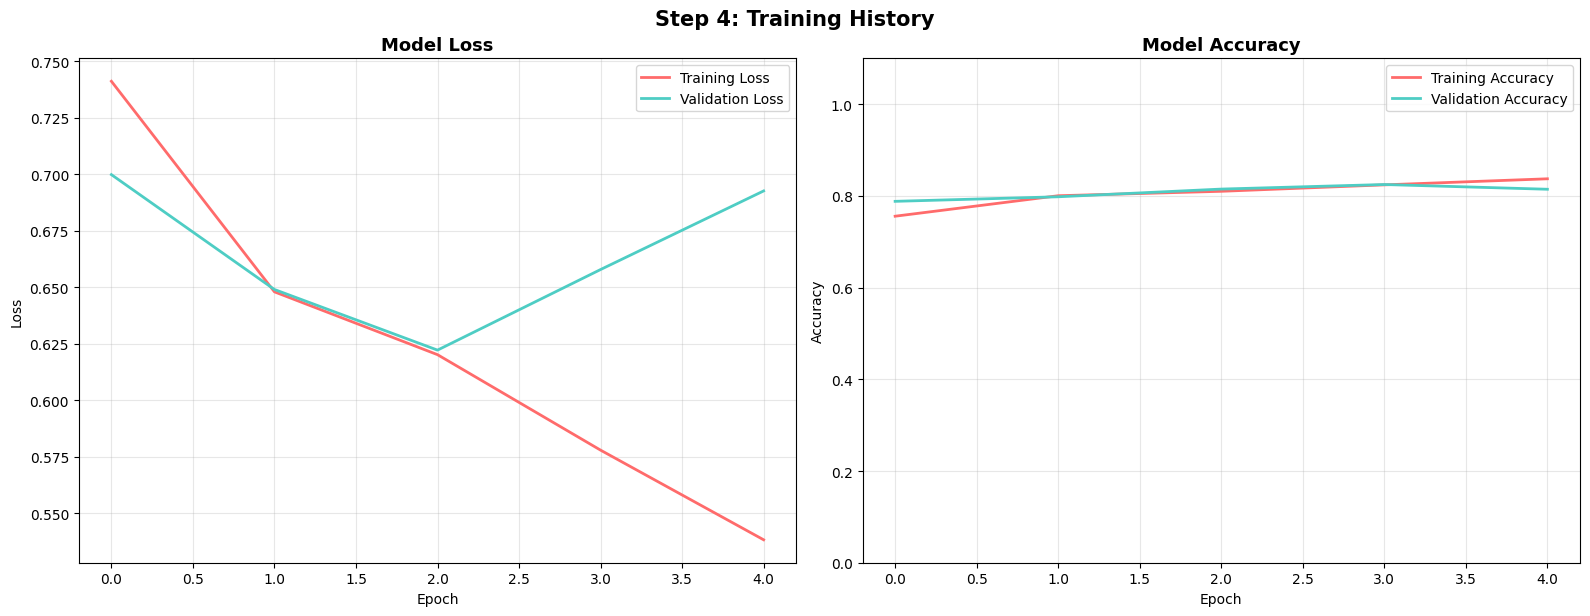


Final Training Accuracy: 0.8373
Final Validation Accuracy: 0.8145


In [37]:
# ============================================================
# STEP 4: MODEL COMPILATION AND TRAINING
# ============================================================

print("\n📌 STEP 4: MODEL COMPILATION AND TRAINING")
print("-" * 50)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
          learning_rate=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


print("Model compiled with:")
print("  - Optimizer: Adam (lr=0.001)")
print("  - Loss: Categorical Crossentropy")
print("  - Metrics: Accuracy")


# ============================================================
# TRAINING PARAMETERS
# ============================================================

EPOCHS = 20
BATCH_SIZE = 64

print(
    f"\nTraining for {EPOCHS} epochs "
    f"with batch size {BATCH_SIZE}..."
)


# ============================================================
# TRAIN MODEL
# ============================================================
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_padded,
    y_train_encoded,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)


# ============================================================
# VISUALIZE TRAINING HISTORY
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


# ============================================================
# LOSS
# ============================================================

ax1 = axes[0]

ax1.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2,
    color="#FF6B6B"
)

ax1.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2,
    color="#4ECDC4"
)

ax1.set_title(
    "Model Loss",
    fontsize=13,
    fontweight="bold"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax1.legend()
ax1.grid(True, alpha=0.3)


# ============================================================
# ACCURACY
# ============================================================

ax2 = axes[1]

ax2.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2,
    color="#FF6B6B"
)

ax2.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2,
    color="#4ECDC4"
)

ax2.set_title(
    "Model Accuracy",
    fontsize=13,
    fontweight="bold"
)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")

ax2.legend()
ax2.grid(True, alpha=0.3)

ax2.set_ylim(0, 1.1)


plt.tight_layout()

plt.suptitle(
    "Step 4: Training History",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.show()


# ============================================================
# FINAL RESULTS
# ============================================================

print(
    f"\nFinal Training Accuracy: "
    f"{history.history['accuracy'][-1]:.4f}"
)

print(
    f"Final Validation Accuracy: "
    f"{history.history['val_accuracy'][-1]:.4f}"
)

In [38]:
from sklearn.metrics import classification_report
import numpy as np

# Predict probabilities on training data
y_train_pred_probs = model.predict(
    X_padded,
    verbose=1
)

# Convert predicted probabilities to class labels
y_train_pred = np.argmax(
    y_train_pred_probs,
    axis=1
)

# Convert true one-hot labels to class labels
y_train_true = np.argmax(
    y_train_encoded,
    axis=1
)

# Print Classification Report
print("\n" + "=" * 60)
print("TRAIN CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_train_true,
        y_train_pred,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        digits=4
    )
)

801/801 ━━━━━━━━━━━━━━━━━━━━ 73s 91ms/step

TRAIN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.8534    0.7248    0.7839      9064
     Neutral     0.2418    0.0183    0.0341      1201
    Positive     0.8141    0.9453    0.8748     15363

    accuracy                         0.8239     25628
   macro avg     0.6364    0.5628    0.5642     25628
weighted avg     0.8012    0.8239    0.8032     25628



In [39]:
# Encode y_test similar to y_train
y_test = np.array(y_test)
y_test_shifted = y_test + 1
y_test_encoded = to_categorical(y_test_shifted, num_classes=3)

y_test_pred_probs = model.predict(
    X_test_padded,
    verbose=1
)

# Convert predictions to class labels
y_test_pred = np.argmax(
    y_test_pred_probs,
    axis=1
)

# Convert true labels from one-hot to class labels
y_test_true = np.argmax(
    y_test_encoded,
    axis=1
)

print("\n" + "=" * 60)
print("TEST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        digits=4
    )
)

201/201 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step

TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.8364    0.6920    0.7574      2276
     Neutral     0.3030    0.0327    0.0590       306
    Positive     0.7988    0.9378    0.8627      3826

    accuracy                         0.8073      6408
   macro avg     0.6461    0.5542    0.5597      6408
weighted avg     0.7885    0.8073    0.7869      6408




📌 STEP 5: STEP-BY-STEP VISUALIZATION OF FORWARD PASS
--------------------------------------------------
Input shape: (5, 374)
Output shape: (5, 3)
Number of attention layers: 2


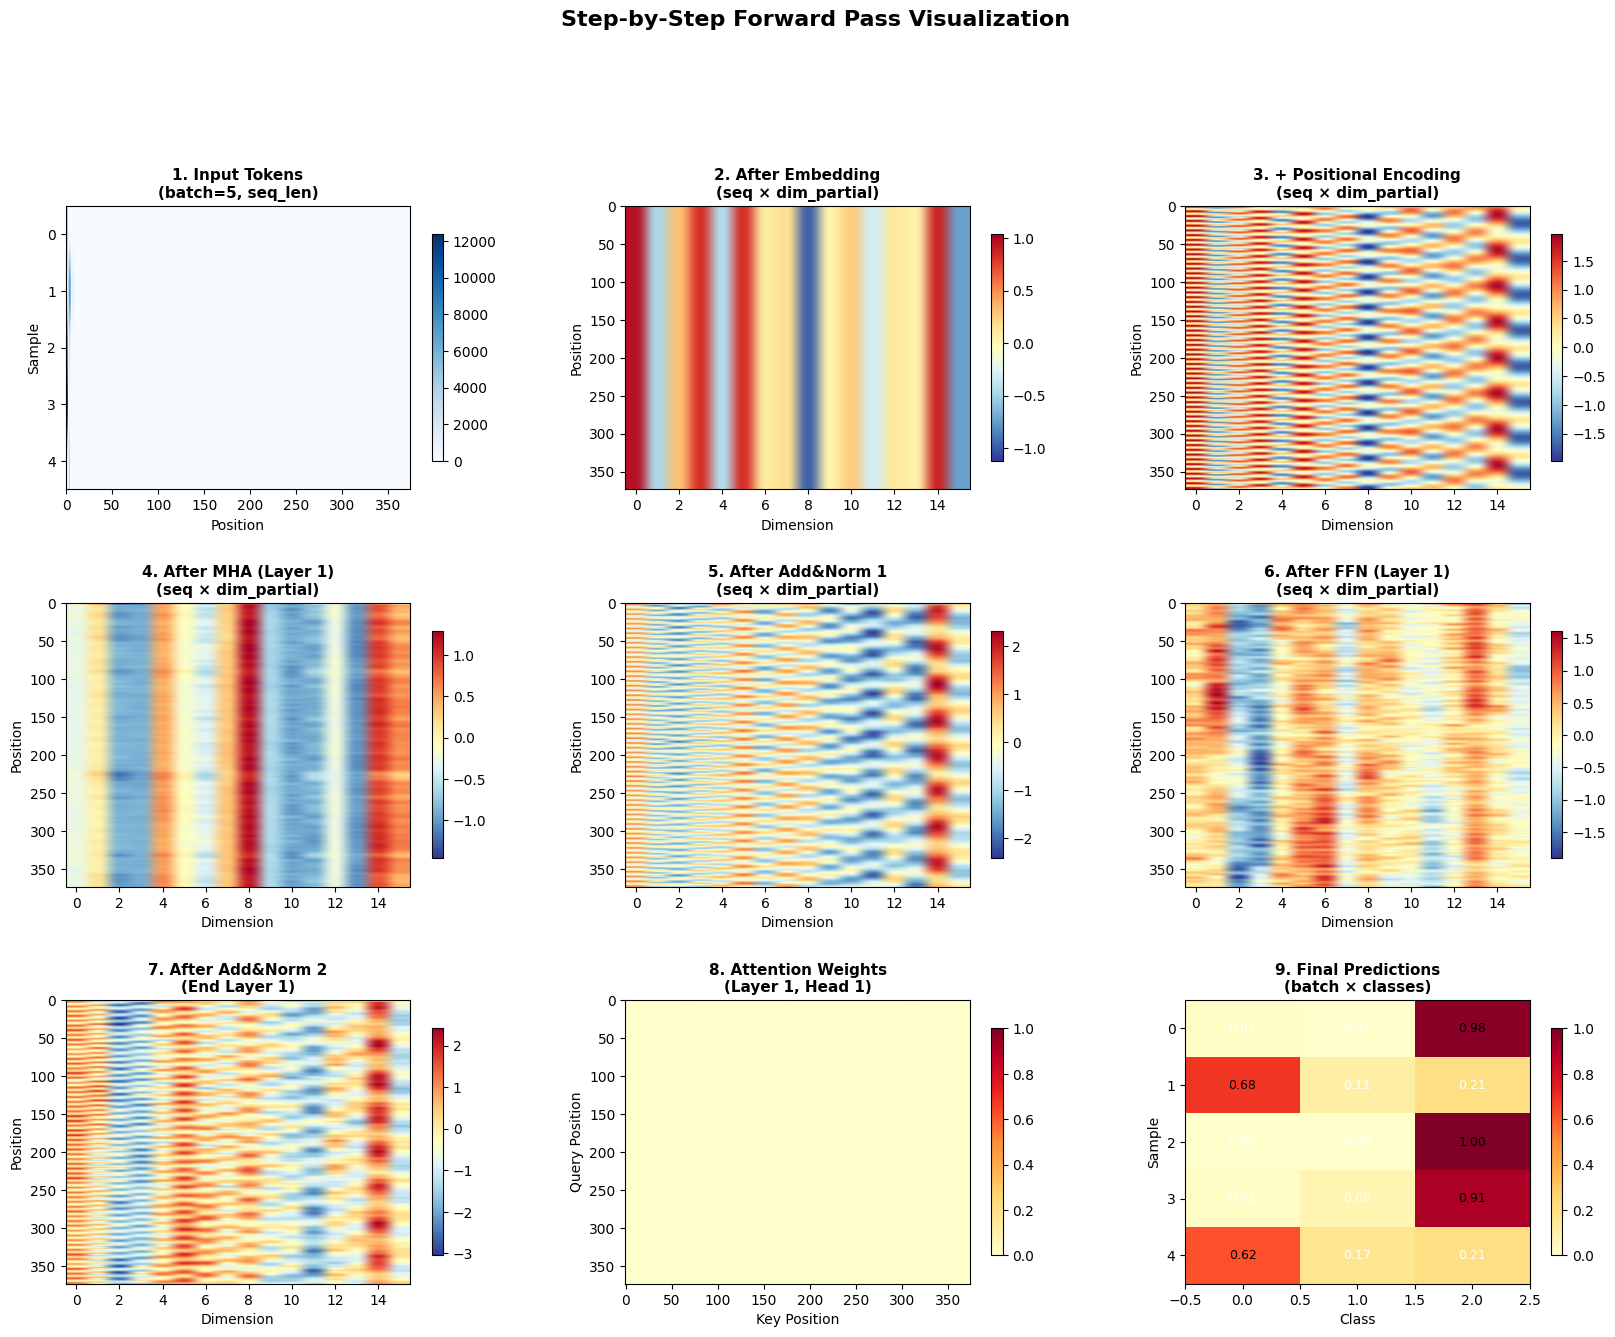

In [40]:
import tensorflow as tf

# ============================================================
# STEP 5: STEP-BY-STEP VISUALIZATION
# ============================================================
print("\n📌 STEP 5: STEP-BY-STEP VISUALIZATION OF FORWARD PASS")
print("-" * 50)

# Get predictions and attention weights
predictions = model(X_padded[:5], training=False)
attention_weights_list = model._attention_weights_list

print(f"Input shape: {X_padded[:5].shape}")
print(f"Output shape: {predictions.shape}")
print(f"Number of attention layers: {len(attention_weights_list)}")

# Visualize each step
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Step 1: Input tokens
ax1 = fig.add_subplot(gs[0, 0])
input_data = X_padded[:5]
im1 = ax1.imshow(input_data, cmap='Blues', aspect='auto')
ax1.set_title('1. Input Tokens\n(batch=5, seq_len)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Position')
ax1.set_ylabel('Sample')
plt.colorbar(im1, ax=ax1, shrink=0.8)

# Step 2: After Embedding
ax2 = fig.add_subplot(gs[0, 1])
embedding_output = model.embedding(X_padded[:5])
embedding_output = model.embedding_projection(embedding_output) # Added missing projection
embedding_output *= tf.math.sqrt(tf.cast(D_MODEL, tf.float32))
emb_data = embedding_output[0, :, :16].numpy()
im2 = ax2.imshow(emb_data, cmap='RdYlBu_r', aspect='auto')
ax2.set_title('2. After Embedding\n(seq × dim_partial)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Dimension')
ax2.set_ylabel('Position')
plt.colorbar(im2, ax=ax2, shrink=0.8)

# Step 3: After Positional Encoding
ax3 = fig.add_subplot(gs[0, 2])
pos_output = model.pos_encoding(embedding_output)
pos_data = pos_output[0, :, :16].numpy()
im3 = ax3.imshow(pos_data, cmap='RdYlBu_r', aspect='auto')
ax3.set_title('3. + Positional Encoding\n(seq × dim_partial)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Dimension')
ax3.set_ylabel('Position')
plt.colorbar(im3, ax=ax3, shrink=0.8)

# Step 4: After MHA (Layer 1)
ax4 = fig.add_subplot(gs[1, 0])
mha_out, _ = model.enc_layers[0].mha(v=pos_output, k=pos_output, q=pos_output)
mha_data = mha_out[0, :, :16].numpy()
im4 = ax4.imshow(mha_data, cmap='RdYlBu_r', aspect='auto')
ax4.set_title('4. After MHA (Layer 1)\n(seq × dim_partial)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Dimension')
ax4.set_ylabel('Position')
plt.colorbar(im4, ax=ax4, shrink=0.8)

# Step 5: After Add&Norm 1
ax5 = fig.add_subplot(gs[1, 1])
an1_out = model.enc_layers[0].add_norm_1(pos_output, mha_out)
an1_data = an1_out[0, :, :16].numpy()
im5 = ax5.imshow(an1_data, cmap='RdYlBu_r', aspect='auto')
ax5.set_title('5. After Add&Norm 1\n(seq × dim_partial)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Dimension')
ax5.set_ylabel('Position')
plt.colorbar(im5, ax=ax5, shrink=0.8)

# Step 6: After FFN
ax6 = fig.add_subplot(gs[1, 2])
ffn_out = model.enc_layers[0].ffn(an1_out)
ffn_data = ffn_out[0, :, :16].numpy()
im6 = ax6.imshow(ffn_data, cmap='RdYlBu_r', aspect='auto')
ax6.set_title('6. After FFN (Layer 1)\n(seq × dim_partial)', fontsize=11, fontweight='bold')
ax6.set_xlabel('Dimension')
ax6.set_ylabel('Position')
plt.colorbar(im6, ax=ax6, shrink=0.8)

# Step 7: After Add&Norm 2
ax7 = fig.add_subplot(gs[2, 0])
an2_out = model.enc_layers[0].add_norm_2(an1_out, ffn_out)
an2_data = an2_out[0, :, :16].numpy()
im7 = ax7.imshow(an2_data, cmap='RdYlBu_r', aspect='auto')
ax7.set_title('7. After Add&Norm 2\n(End Layer 1)', fontsize=11, fontweight='bold')
ax7.set_xlabel('Dimension')
ax7.set_ylabel('Position')
plt.colorbar(im7, ax=ax7, shrink=0.8)

# Step 8: Attention Weights (Layer 1, Head 1)
ax8 = fig.add_subplot(gs[2, 1])
attn_data = attention_weights_list[0][0, 0, :, :].numpy()
im8 = ax8.imshow(attn_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax8.set_title('8. Attention Weights\n(Layer 1, Head 1)', fontsize=11, fontweight='bold')
ax8.set_xlabel('Key Position')
ax8.set_ylabel('Query Position')
plt.colorbar(im8, ax=ax8, shrink=0.8)

# Step 9: Predictions
ax9 = fig.add_subplot(gs[2, 2])
pred_data = predictions.numpy()
im9 = ax9.imshow(pred_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax9.set_title('9. Final Predictions\n(batch × classes)', fontsize=11, fontweight='bold')
ax9.set_xlabel('Class')
ax9.set_ylabel('Sample')
plt.colorbar(im9, ax=ax9, shrink=0.8)

# Add text annotations to predictions
for i in range(min(5, pred_data.shape[0])):
    for j in range(pred_data.shape[1]):
        val = pred_data[i, j]
        ax9.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color='black' if val > 0.5 else 'white')

plt.suptitle('Step-by-Step Forward Pass Visualization',
             fontsize=16, fontweight='bold', y=1.02)
plt.show()


📌 STEP 6: ATTENTION WEIGHT VISUALIZATION
--------------------------------------------------


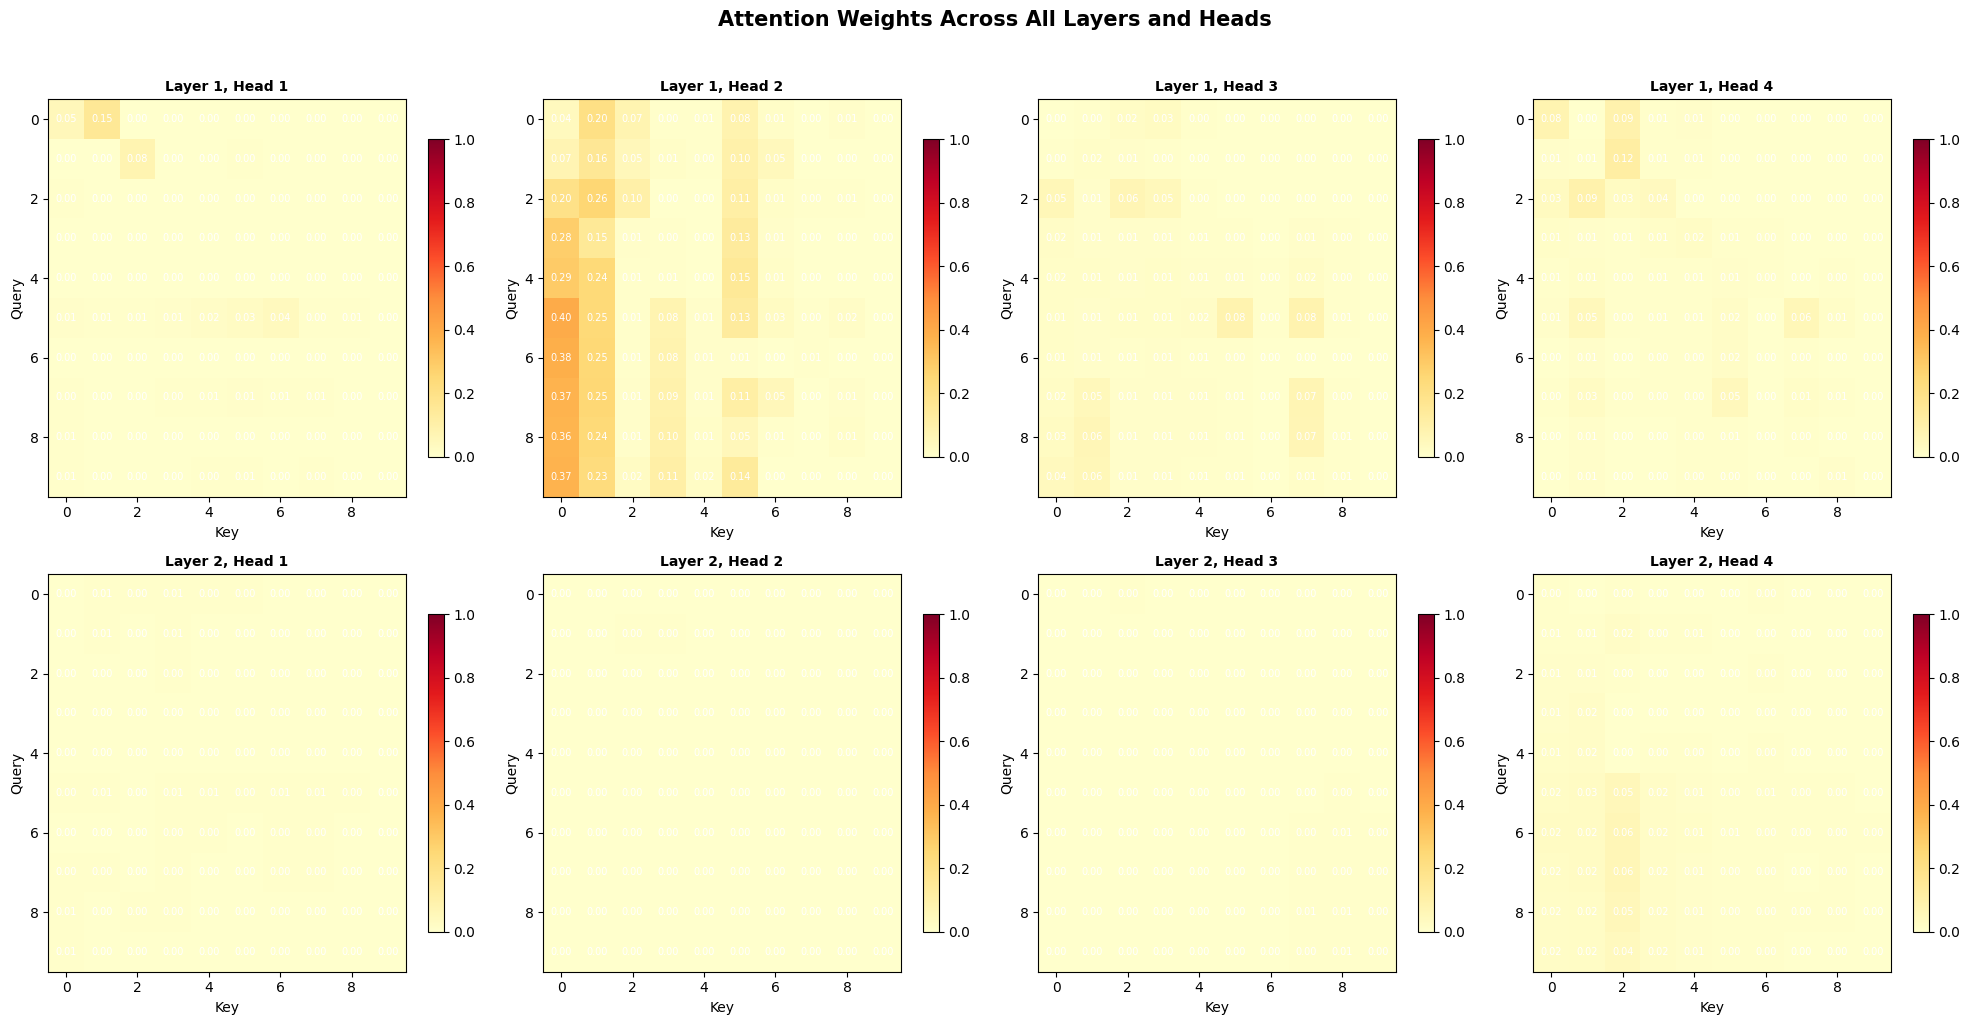

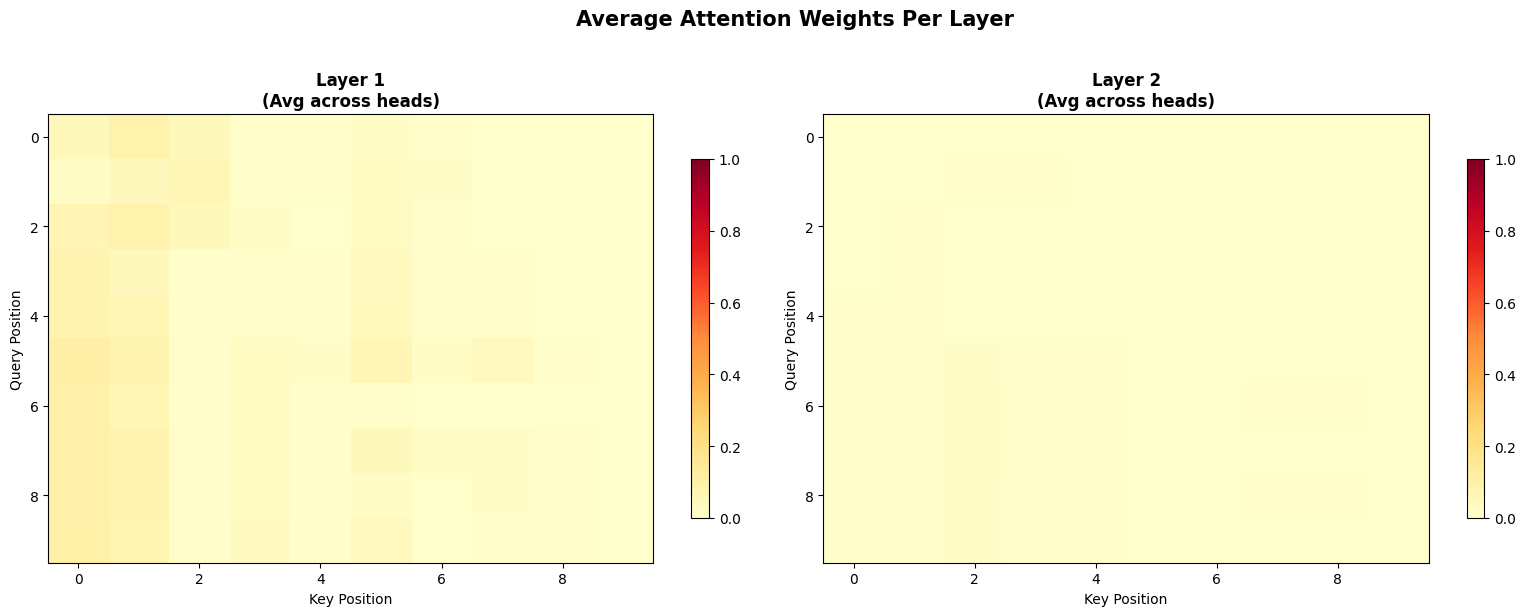

In [41]:
# ============================================================
# STEP 6: ATTENTION WEIGHT VISUALIZATION
# ============================================================
print("\n📌 STEP 6: ATTENTION WEIGHT VISUALIZATION")
print("-" * 50)

# Visualize attention weights for all heads and layers
num_layers = len(attention_weights_list)
num_heads = attention_weights_list[0].shape[1]

fig, axes = plt.subplots(num_layers, num_heads, figsize=(20, 10))

for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        ax = axes[layer_idx, head_idx] if num_layers > 1 else axes[head_idx]

        # Average attention weights across batch
        attn_weights = np.mean(attention_weights_list[layer_idx][:, head_idx, :, :], axis=0)

        # Show first 10 positions
        attn_data = attn_weights[:10, :10]

        im = ax.imshow(attn_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
        ax.set_title(f'Layer {layer_idx+1}, Head {head_idx+1}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Key')
        ax.set_ylabel('Query')

        # Add text annotations
        for i in range(10):
            for j in range(10):
                val = attn_data[i, j]
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                       fontsize=7, color='black' if val > 0.5 else 'white')

        plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Attention Weights Across All Layers and Heads',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Visualize average attention across all heads for each layer
fig, axes = plt.subplots(1, num_layers, figsize=(16, 6))

for layer_idx in range(num_layers):
    ax = axes[layer_idx] if num_layers > 1 else axes

    # Average across batch and heads
    attn_weights = np.mean(attention_weights_list[layer_idx], axis=(0, 1))
    attn_data = attn_weights[:10, :10]

    im = ax.imshow(attn_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_title(f'Layer {layer_idx+1}\n(Avg across heads)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Key Position')
    ax.set_ylabel('Query Position')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Average Attention Weights Per Layer',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

 # STEP 7: PREDICTION AND EVALUATION


📌 STEP 7: PREDICTION AND EVALUATION
--------------------------------------------------
101/101 ━━━━━━━━━━━━━━━━━━━━ 20s 194ms/step
Test Predictions:
--------------------------------------------------

Sample 1:
  Text: 'الثلاثاء القادم مرحبا بك يا'
  Predicted Class: 2
  Probabilities: [0.10338495 0.01793837 0.8786767 ]
  Confidence: 0.8787

Sample 2:
  Text: 'اعجبني بصراحه وما احس الاسعار فيه غاليه والتوصيل جدا راءعOKhandthumbsup'
  Predicted Class: 2
  Probabilities: [0.00706369 0.01525963 0.97767663]
  Confidence: 0.9777

Sample 3:
  Text: 'مافي ماكدونالدز'
  Predicted Class: 2
  Probabilities: [0.37504926 0.08782412 0.53712666]
  Confidence: 0.5371

Sample 4:
  Text: 'الطلب وصلني ناقص مع علم المطعم مع ذلك تم اخذ مبلغ كامل والي الان من 10 ايام يماطل موقع طلبات باعذار غير منطقيه المبلغ تم اخذه كاش التطبيق فاشل جدا جدا'
  Predicted Class: 0
  Probabilities: [0.991952   0.00272205 0.005326  ]
  Confidence: 0.9920

Sample 5:
  Text: 'انا عايز اشتري ابلكيشن طالبات'
  Predicted Class: 0


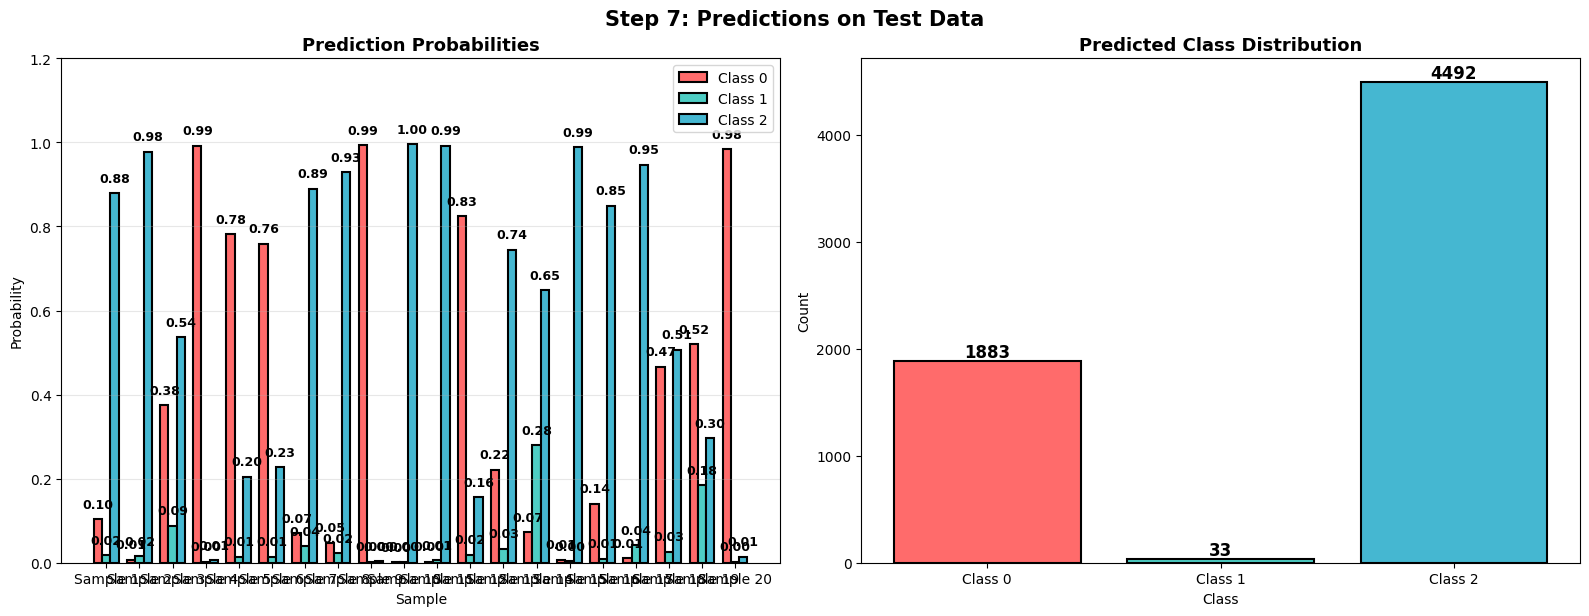

In [42]:
print("\n📌 STEP 7: PREDICTION AND EVALUATION")
print("-" * 50)

# Predict on test set using batching to avoid ResourceExhaustedError
test_predictions = model.predict(X_test_padded, batch_size=BATCH_SIZE)
test_pred_classes = np.argmax(test_predictions, axis=1)

print("Test Predictions:")
print("-" * 50)
# Retrieve attention weights if needed for a small sample, as model.predict doesn't populate it.
# For full test set attention weights, a separate batched loop would be required, or model(X_test_padded[:N], training=False).
# For the purpose of this cell, `test_attn_weights` is no longer directly available for the entire test set.

for i, (text, pred_class, pred_probs) in enumerate(zip(x_test, test_pred_classes, test_predictions)):
    if i < 5: # Limit printing to first 5 samples for brevity
        print(f"\nSample {i+1}:")
        print(f"  Text: '{text}'")
        print(f"  Predicted Class: {pred_class}")
        print(f"  Probabilities: {pred_probs}")
        print(f"  Confidence: {np.max(pred_probs):.4f}")

# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prediction probabilities
ax1 = axes[0]
pred_probs_data = test_predictions
x_pos = np.arange(len(x_test))
width = 0.25

# Only show a subset for visualization if test_predictions is too large
num_samples_to_show = min(len(x_test), 20) # Show up to 20 samples

for class_idx in range(NUM_CLASSES):
    probs = pred_probs_data[:num_samples_to_show, class_idx]
    bars = ax1.bar(np.arange(num_samples_to_show) + class_idx * width, probs, width,
                   label=f'Class {class_idx}',
                   color=['#FF6B6B', '#4ECDC4', '#45B7D1'][class_idx],
                   edgecolor='black', linewidth=1.5)

    # Add value labels
    for bar, prob in zip(bars, probs):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{prob:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('Sample')
ax1.set_ylabel('Probability')
ax1.set_title('Prediction Probabilities', fontsize=13, fontweight='bold')
ax1.set_xticks(np.arange(num_samples_to_show) + width)
ax1.set_xticklabels([f'Sample {i+1}' for i in range(num_samples_to_show)])
ax1.legend()
ax1.set_ylim(0, 1.2)
ax1.grid(True, alpha=0.3, axis='y')

# Confusion matrix (if we had true labels)
ax2 = axes[1]
# For demonstration, show predicted class distribution
pred_counts = np.bincount(test_pred_classes, minlength=NUM_CLASSES)
bars = ax2.bar(['Class 0', 'Class 1', 'Class 2'], pred_counts,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
               edgecolor='black', linewidth=1.5)
ax2.set_title('Predicted Class Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Class')
ax2.set_ylabel('Count')

for bar, count in zip(bars, pred_counts):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            str(int(count)), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.suptitle('Step 7: Predictions on Test Data', fontsize=15, fontweight='bold', y=1.02)
plt.show()


 STEP 8: SAVE MODEL AND CREATE INFERENCE FUNCTION
--------------------------------------------------
Model saved to 'transformer_encoder_classifier.keras'

Testing inference function:
--------------------------------------------------

Text: 'This is an amazing product'
  Predicted Class: 2
  Confidence: 0.9886
  Probabilities: [0.00774465 0.00368002 0.9885753 ]

Text: 'I am very disappointed'
  Predicted Class: 2
  Confidence: 0.9957
  Probabilities: [0.00252608 0.00181571 0.99565816]

Text: 'It is okay I guess'
  Predicted Class: 2
  Confidence: 0.9955
  Probabilities: [0.00265151 0.00189153 0.99545693]


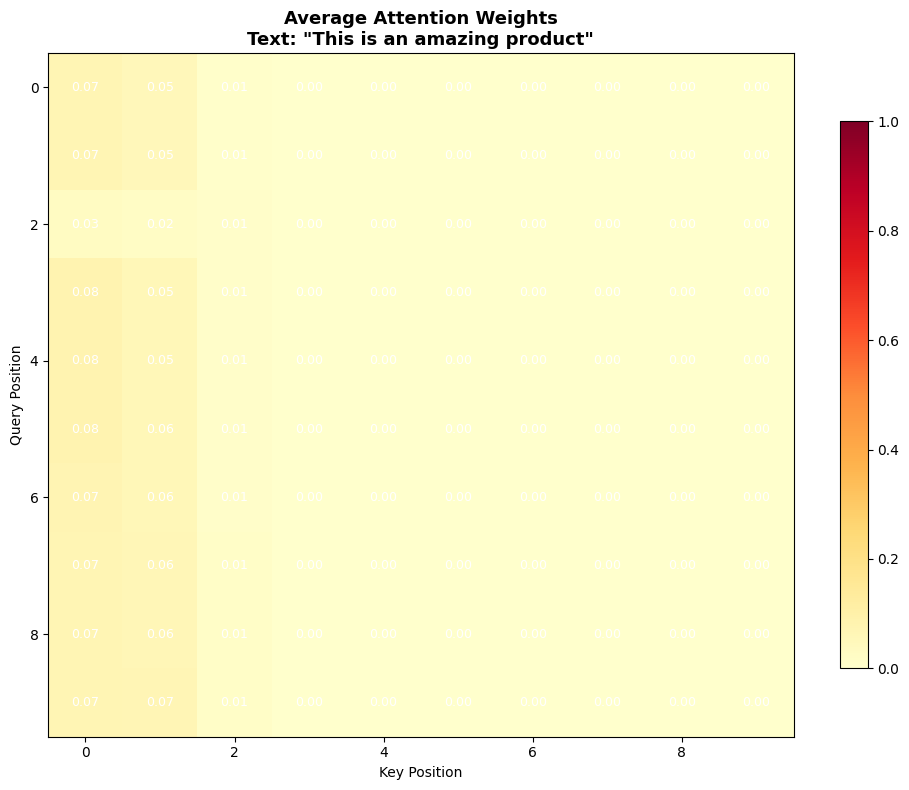


✅ TRANSFORMER ENCODER IMPLEMENTATION COMPLETE!

Files saved:
  - tokenizer.pickle: Tokenizer for text preprocessing
  - transformer_encoder_classifier.keras: Trained model

Usage:
  pred_class, confidence, probs, attn = predict_class(text, model, tokenizer, max_len)


In [43]:
# ============================================================
# STEP 8: SAVE MODEL AND CREATE INFERENCE FUNCTION
# ============================================================
print("\n STEP 8: SAVE MODEL AND CREATE INFERENCE FUNCTION")
print("-" * 50)

# Save model in native Keras format
model.save('../models/transformer_encoder_classifier.keras')
print("Model saved to 'transformer_encoder_classifier.keras'")

# Create inference function
def predict_class(text, model, tokenizer, max_len):
    """
    Predict class for a single text input
    """
    # Tokenize
    tokenized = tokenizer.texts_to_sequences([text])

    # Pad
    padded = pad_sequences(tokenized, maxlen=max_len, padding='post')

    # Predict
    predictions = model(padded, training=False)
    attn_weights = model._attention_weights_list # Retrieve attention weights

    # Get class
    pred_class = np.argmax(predictions, axis=1)[0]
    confidence = np.max(predictions.numpy())
    probabilities = predictions.numpy()[0]

    return pred_class, confidence, probabilities, attn_weights

# Test inference function
print("\nTesting inference function:")
print("-" * 50)

test_texts = [
    "This is an amazing product",
    "I am very disappointed",
    "It is okay I guess"
]

for text in test_texts:
    pred_class, confidence, probabilities, attn_weights = predict_class(
        text, model, tokenizer, MAX_LEN
    )

    print(f"\nText: '{text}'")
    print(f"  Predicted Class: {pred_class}")
    print(f"  Confidence: {confidence:.4f}")
    print(f"  Probabilities: {probabilities}")

# Visualize attention for a specific prediction
fig, ax = plt.subplots(figsize=(10, 8))

# Get attention weights for first test text
_, _, _, attn_weights = predict_class(test_texts[0], model, tokenizer, MAX_LEN)

# Show average attention across all heads and layers
avg_attn = np.mean([np.mean(layer_attn[0], axis=0) for layer_attn in attn_weights], axis=0)

# Show first 10 positions
attn_data = avg_attn[:10, :10]
im = ax.imshow(attn_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax.set_title(f'Average Attention Weights\nText: "{test_texts[0]}"',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')

# Add text annotations
for i in range(10):
    for j in range(10):
        val = attn_data[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
               fontsize=9, color='black' if val > 0.5 else 'white')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("✅ TRANSFORMER ENCODER IMPLEMENTATION COMPLETE!")
print("=" * 70)
print("\nFiles saved:")
print("  - tokenizer.pickle: Tokenizer for text preprocessing")
print("  - transformer_encoder_classifier.keras: Trained model")
print("\nUsage:")
print("  pred_class, confidence, probs, attn = predict_class(text, model, tokenizer, max_len)")